# Healthcare Analytics SQL Project
### Using SQLite + Pandas in Jupyter Notebook

**No MySQL needed.** This notebook runs entirely on SQLite which is built into Python.

---

**How to use this notebook:**
- Run cells in order from top to bottom
- Press **Shift + Enter** to run a cell and move to the next one
- Press **Ctrl + Enter** to run a cell and stay on it
- Cell 1 sets everything up — run it first every time you open this notebook

---

In [1]:
# ============================================================
# CELL 1 — Setup: import libraries and create the database
# Run this first every time. Takes about 2 seconds.
# ============================================================

import sqlite3
import pandas as pd

# Makes tables display nicely
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 120)

# Create database in memory (or change ':memory:' to 'healthcare.db' to save to disk)
conn = sqlite3.connect(':memory:')

# Helper function — run any SQL and see results as a table
def run(sql):
    return pd.read_sql_query(sql, conn)

print('Libraries loaded. Database ready.')

Libraries loaded. Database ready.


In [2]:
# ============================================================
# CELL 2 — Create tables
# ============================================================

conn.executescript("""
    DROP TABLE IF EXISTS diagnoses;
    DROP TABLE IF EXISTS admissions;
    DROP TABLE IF EXISTS patients;

    CREATE TABLE patients (
        patient_id      INTEGER PRIMARY KEY,
        first_name      TEXT,
        last_name       TEXT,
        date_of_birth   TEXT,
        gender          TEXT,
        zip_code        TEXT,
        insurance_type  TEXT
    );

    CREATE TABLE admissions (
        admission_id    INTEGER PRIMARY KEY,
        patient_id      INTEGER,
        admission_date  TEXT,
        discharge_date  TEXT,
        department      TEXT,
        admission_type  TEXT,
        attending_md    TEXT
    );

    CREATE TABLE diagnoses (
        diagnosis_id            INTEGER PRIMARY KEY,
        admission_id            INTEGER,
        patient_id              INTEGER,
        icd_code                TEXT,
        diagnosis_description   TEXT,
        diagnosis_type          TEXT
    );
""")

print('Tables created successfully.')

Tables created successfully.


In [3]:
# ============================================================
# CELL 3 — Load sample data (20 patients, 40 admissions, 40 diagnoses)
# ============================================================

patients = [
    (1001,'Maria','Gonzalez','1958-03-14','Female','21201','Medicare'),
    (1002,'James','Wilson','1945-07-22','Male','21202','Medicaid'),
    (1003,'Linda','Chen','1972-11-05','Female','21203','Commercial'),
    (1004,'Robert','Johnson','1960-01-30','Male','21204','Medicare'),
    (1005,'Susan','Patel','1985-06-18','Female','21205','Commercial'),
    (1006,'David','Kim','1952-09-09','Male','21206','Medicare'),
    (1007,'Barbara','Thomas','1940-12-25','Female','21207','Medicaid'),
    (1008,'Michael','Brown','1978-04-03','Male','21208','Commercial'),
    (1009,'Jennifer','Davis','1965-08-17','Female','21209','Medicare'),
    (1010,'William','Martinez','1955-02-28','Male','21210','Medicaid'),
    (1011,'Patricia','Anderson','1990-10-11','Female','21211','Commercial'),
    (1012,'Charles','Taylor','1948-05-07','Male','21212','Medicare'),
    (1013,'Dorothy','White','1970-03-22','Female','21213','Commercial'),
    (1014,'Thomas','Harris','1963-07-14','Male','21214','Medicaid'),
    (1015,'Nancy','Jackson','1982-01-09','Female','21215','Commercial'),
    (1016,'Steven','Lopez','1957-11-30','Male','21216','Medicare'),
    (1017,'Karen','Lee','1944-06-19','Female','21217','Medicare'),
    (1018,'Jason','Walker','1988-09-25','Male','21218','Commercial'),
    (1019,'Betty','Hall','1935-04-01','Female','21219','Medicare'),
    (1020,'Edward','Young','1975-12-15','Male','21220','Medicaid'),
]

admissions = [
    (5001,1001,'2024-01-05','2024-01-09','Cardiology','Emergency','Dr. Smith'),
    (5002,1001,'2024-01-28','2024-02-01','Cardiology','Urgent','Dr. Smith'),
    (5003,1002,'2024-01-10','2024-01-15','Internal Med','Emergency','Dr. Jones'),
    (5004,1003,'2024-01-12','2024-01-14','Orthopedics','Elective','Dr. Brown'),
    (5005,1004,'2024-01-15','2024-01-22','Cardiology','Emergency','Dr. Smith'),
    (5006,1004,'2024-02-10','2024-02-14','Cardiology','Urgent','Dr. Smith'),
    (5007,1005,'2024-01-18','2024-01-20','Obstetrics','Elective','Dr. Lee'),
    (5008,1006,'2024-01-20','2024-01-27','Internal Med','Emergency','Dr. Jones'),
    (5009,1006,'2024-02-08','2024-02-12','Internal Med','Urgent','Dr. Jones'),
    (5010,1007,'2024-01-22','2024-02-02','Neurology','Emergency','Dr. Patel'),
    (5011,1008,'2024-01-25','2024-01-27','Orthopedics','Elective','Dr. Brown'),
    (5012,1009,'2024-01-28','2024-02-04','Cardiology','Emergency','Dr. Smith'),
    (5013,1009,'2024-02-20','2024-02-24','Cardiology','Urgent','Dr. Smith'),
    (5014,1010,'2024-02-01','2024-02-08','Internal Med','Emergency','Dr. Jones'),
    (5015,1011,'2024-02-03','2024-02-05','Obstetrics','Elective','Dr. Lee'),
    (5016,1012,'2024-02-05','2024-02-12','Neurology','Emergency','Dr. Patel'),
    (5017,1012,'2024-02-25','2024-03-01','Neurology','Urgent','Dr. Patel'),
    (5018,1013,'2024-02-08','2024-02-11','Orthopedics','Elective','Dr. Brown'),
    (5019,1014,'2024-02-10','2024-02-18','Internal Med','Emergency','Dr. Jones'),
    (5020,1015,'2024-02-12','2024-02-14','Obstetrics','Elective','Dr. Lee'),
    (5021,1016,'2024-02-15','2024-02-22','Cardiology','Emergency','Dr. Smith'),
    (5022,1016,'2024-03-05','2024-03-09','Cardiology','Urgent','Dr. Smith'),
    (5023,1017,'2024-02-18','2024-03-01','Neurology','Emergency','Dr. Patel'),
    (5024,1018,'2024-02-20','2024-02-22','Orthopedics','Elective','Dr. Brown'),
    (5025,1019,'2024-02-22','2024-03-05','Internal Med','Emergency','Dr. Jones'),
    (5026,1019,'2024-03-18','2024-03-22','Internal Med','Urgent','Dr. Jones'),
    (5027,1020,'2024-02-25','2024-03-01','Cardiology','Emergency','Dr. Smith'),
    (5028,1001,'2024-03-10','2024-03-14','Cardiology','Urgent','Dr. Smith'),
    (5029,1002,'2024-03-12','2024-03-18','Internal Med','Emergency','Dr. Jones'),
    (5030,1004,'2024-03-15','2024-03-20','Cardiology','Emergency','Dr. Smith'),
    (5031,1006,'2024-03-20','2024-03-26','Internal Med','Emergency','Dr. Jones'),
    (5032,1007,'2024-03-22','2024-04-01','Neurology','Emergency','Dr. Patel'),
    (5033,1010,'2024-03-25','2024-04-02','Internal Med','Emergency','Dr. Jones'),
    (5034,1012,'2024-03-28','2024-04-04','Neurology','Emergency','Dr. Patel'),
    (5035,1014,'2024-04-01','2024-04-08','Internal Med','Emergency','Dr. Jones'),
    (5036,1016,'2024-04-05','2024-04-10','Cardiology','Urgent','Dr. Smith'),
    (5037,1019,'2024-04-08','2024-04-15','Internal Med','Urgent','Dr. Jones'),
    (5038,1003,'2024-04-10','2024-04-13','Orthopedics','Elective','Dr. Brown'),
    (5039,1008,'2024-04-12','2024-04-15','Orthopedics','Elective','Dr. Brown'),
    (5040,1020,'2024-04-15','2024-04-20','Internal Med','Emergency','Dr. Jones'),
]

diagnoses = [
    (9001,5001,1001,'I21.0','Acute MI anterior wall','Primary'),
    (9002,5001,1001,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9003,5002,1001,'I50.9','Heart failure unspecified','Primary'),
    (9004,5003,1002,'J18.9','Pneumonia unspecified','Primary'),
    (9005,5003,1002,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9006,5004,1003,'M17.11','Primary osteoarthritis right knee','Primary'),
    (9007,5005,1004,'I21.9','Acute MI unspecified','Primary'),
    (9008,5005,1004,'I10','Essential hypertension','Secondary'),
    (9009,5005,1004,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9010,5006,1004,'I50.9','Heart failure unspecified','Primary'),
    (9011,5008,1006,'J44.1','COPD with acute exacerbation','Primary'),
    (9012,5008,1006,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9013,5009,1006,'J44.1','COPD with acute exacerbation','Primary'),
    (9014,5010,1007,'I63.9','Cerebral infarction unspecified','Primary'),
    (9015,5012,1009,'I21.0','Acute MI anterior wall','Primary'),
    (9016,5012,1009,'I10','Essential hypertension','Secondary'),
    (9017,5013,1009,'I50.9','Heart failure unspecified','Primary'),
    (9018,5014,1010,'J18.9','Pneumonia unspecified','Primary'),
    (9019,5014,1010,'E11.65','Type 2 diabetes with hypoglycemia','Secondary'),
    (9020,5016,1012,'I63.9','Cerebral infarction unspecified','Primary'),
    (9021,5016,1012,'I10','Essential hypertension','Secondary'),
    (9022,5017,1012,'G45.9','TIA unspecified','Primary'),
    (9023,5019,1014,'J18.9','Pneumonia unspecified','Primary'),
    (9024,5019,1014,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9025,5021,1016,'I21.9','Acute MI unspecified','Primary'),
    (9026,5021,1016,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9027,5022,1016,'I50.9','Heart failure unspecified','Primary'),
    (9028,5023,1017,'I63.9','Cerebral infarction unspecified','Primary'),
    (9029,5025,1019,'J18.9','Pneumonia unspecified','Primary'),
    (9030,5025,1019,'E11.65','Type 2 diabetes with hypoglycemia','Secondary'),
    (9031,5026,1019,'J18.9','Pneumonia unspecified','Primary'),
    (9032,5027,1020,'I21.9','Acute MI unspecified','Primary'),
    (9033,5027,1020,'E11.9','Type 2 diabetes uncontrolled','Secondary'),
    (9034,5029,1002,'J44.1','COPD with acute exacerbation','Primary'),
    (9035,5030,1004,'I50.9','Heart failure unspecified','Primary'),
    (9036,5031,1006,'J44.1','COPD with acute exacerbation','Primary'),
    (9037,5033,1010,'J18.9','Pneumonia unspecified','Primary'),
    (9038,5034,1012,'I63.9','Cerebral infarction unspecified','Primary'),
    (9039,5035,1014,'J18.9','Pneumonia unspecified','Primary'),
    (9040,5040,1020,'J18.9','Pneumonia unspecified','Primary'),
]

conn.executescript('DELETE FROM diagnoses; DELETE FROM admissions; DELETE FROM patients;')
conn.executemany('INSERT INTO patients VALUES (?,?,?,?,?,?,?)', patients)
conn.executemany('INSERT INTO admissions VALUES (?,?,?,?,?,?,?)', admissions)
conn.executemany('INSERT INTO diagnoses VALUES (?,?,?,?,?,?)', diagnoses)
conn.commit()

print(f'Loaded: {len(patients)} patients, {len(admissions)} admissions, {len(diagnoses)} diagnoses')

Loaded: 20 patients, 40 admissions, 40 diagnoses


---
## Queries
Run each cell below independently. Results display as a table automatically.

---

In [4]:
# ============================================================
# QUERY 1 — Total admissions by department
# Concept: Basic GROUP BY + ORDER BY
# ============================================================

run("""
    SELECT
        department,
        COUNT(*) AS total_admissions
    FROM admissions
    GROUP BY department
    ORDER BY total_admissions DESC
""")

,department,total_admissions
0,Internal Med,13
1,Cardiology,12
2,Orthopedics,6
3,Neurology,6
4,Obstetrics,3


In [5]:
# ============================================================
# QUERY 2 — Average length of stay by department
# Concept: Date math with JULIANDAY (SQLite version of DATEDIFF)
# ============================================================

run("""
    SELECT
        department,
        COUNT(*)                                                            AS total_admissions,
        ROUND(AVG(JULIANDAY(discharge_date) - JULIANDAY(admission_date)),1) AS avg_los_days,
        MIN(JULIANDAY(discharge_date) - JULIANDAY(admission_date))          AS min_los_days,
        MAX(JULIANDAY(discharge_date) - JULIANDAY(admission_date))          AS max_los_days
    FROM admissions
    GROUP BY department
    ORDER BY avg_los_days DESC
""")

,department,total_admissions,avg_los_days,min_los_days,max_los_days
0,Neurology,6,8.7,5.0,12.0
1,Internal Med,13,6.6,4.0,12.0
2,Cardiology,12,5.0,4.0,7.0
3,Orthopedics,6,2.5,2.0,3.0
4,Obstetrics,3,2.0,2.0,2.0


In [6]:
# ============================================================
# QUERY 3 — Admissions by insurance type
# Concept: JOIN across two tables
# ============================================================

run("""
    SELECT
        p.insurance_type,
        COUNT(a.admission_id)        AS total_admissions,
        COUNT(DISTINCT a.patient_id) AS unique_patients
    FROM admissions a
    JOIN patients p ON a.patient_id = p.patient_id
    GROUP BY p.insurance_type
    ORDER BY total_admissions DESC
""")

,insurance_type,total_admissions,unique_patients
0,Medicare,21,8
1,Medicaid,10,5
2,Commercial,9,7


In [7]:
# ============================================================
# QUERY 4 — Emergency vs elective vs urgent per department
# Concept: CASE WHEN conditional aggregation
# ============================================================

run("""
    SELECT
        department,
        COUNT(*)                                                              AS total,
        SUM(CASE WHEN admission_type = 'Emergency' THEN 1 ELSE 0 END)        AS emergency,
        SUM(CASE WHEN admission_type = 'Elective'  THEN 1 ELSE 0 END)        AS elective,
        SUM(CASE WHEN admission_type = 'Urgent'    THEN 1 ELSE 0 END)        AS urgent,
        ROUND(
            100.0 * SUM(CASE WHEN admission_type = 'Emergency' THEN 1 ELSE 0 END) / COUNT(*)
        , 1)                                                                  AS emergency_pct
    FROM admissions
    GROUP BY department
    ORDER BY emergency_pct DESC
""")

,department,total,emergency,elective,urgent,emergency_pct
0,Neurology,6,5,0,1,83.3
1,Internal Med,13,10,0,3,76.9
2,Cardiology,12,6,0,6,50.0
3,Orthopedics,6,0,6,0,0.0
4,Obstetrics,3,0,3,0,0.0


In [8]:
# ============================================================
# QUERY 5 — Top primary diagnoses
# Concept: Filter on ICD type, count across patients
# ============================================================

run("""
    SELECT
        icd_code,
        diagnosis_description,
        COUNT(*)                     AS diagnosis_count,
        COUNT(DISTINCT patient_id)   AS unique_patients
    FROM diagnoses
    WHERE diagnosis_type = 'Primary'
    GROUP BY icd_code, diagnosis_description
    ORDER BY diagnosis_count DESC
    LIMIT 10
""")

,icd_code,diagnosis_description,diagnosis_count,unique_patients
0,J18.9,Pneumonia unspecified,8,5
1,I50.9,Heart failure unspecified,5,4
2,I63.9,Cerebral infarction unspecified,4,3
3,J44.1,COPD with acute exacerbation,4,2
4,I21.9,Acute MI unspecified,3,3
5,I21.0,Acute MI anterior wall,2,2
6,G45.9,TIA unspecified,1,1
7,M17.11,Primary osteoarthritis right knee,1,1


In [9]:
# ============================================================
# QUERY 6 — 30-day readmission events
# Concept: Self JOIN — compare each visit to future visits
# This is one of the most common healthcare SQL interview patterns
# ============================================================

run("""
    SELECT
        a1.patient_id,
        p.first_name || ' ' || p.last_name             AS patient_name,
        a1.department,
        a1.discharge_date                               AS first_discharge,
        a2.admission_date                               AS readmit_date,
        CAST(
            JULIANDAY(a2.admission_date) - JULIANDAY(a1.discharge_date)
        AS INTEGER)                                     AS days_between
    FROM admissions a1
    JOIN admissions a2
        ON  a1.patient_id = a2.patient_id
        AND a2.admission_date > a1.discharge_date
        AND (JULIANDAY(a2.admission_date) - JULIANDAY(a1.discharge_date)) <= 30
    JOIN patients p ON a1.patient_id = p.patient_id
    ORDER BY a1.patient_id, a1.discharge_date
""")

,patient_id,patient_name,department,first_discharge,readmit_date,days_between
0,1001,Maria Gonzalez,Cardiology,2024-01-09,2024-01-28,19
1,1004,Robert Johnson,Cardiology,2024-01-22,2024-02-10,19
2,1004,Robert Johnson,Cardiology,2024-02-14,2024-03-15,30
3,1006,David Kim,Internal Med,2024-01-27,2024-02-08,12
4,1009,Jennifer Davis,Cardiology,2024-02-04,2024-02-20,16
5,1012,Charles Taylor,Neurology,2024-02-12,2024-02-25,13
6,1012,Charles Taylor,Neurology,2024-03-01,2024-03-28,27
7,1016,Steven Lopez,Cardiology,2024-02-22,2024-03-05,12
8,1016,Steven Lopez,Cardiology,2024-03-09,2024-04-05,27
9,1019,Betty Hall,Internal Med,2024-03-05,2024-03-18,13


In [10]:
# ============================================================
# QUERY 7 — 30-day readmission RATE by department
# Concept: CTE (WITH clause) + LEFT JOIN
# ============================================================

run("""
    WITH readmits AS (
        SELECT DISTINCT
            a1.patient_id,
            a1.department,
            a1.discharge_date
        FROM admissions a1
        JOIN admissions a2
            ON  a1.patient_id = a2.patient_id
            AND a2.admission_date > a1.discharge_date
            AND (JULIANDAY(a2.admission_date) - JULIANDAY(a1.discharge_date)) <= 30
    )
    SELECT
        a.department,
        COUNT(*)                                                    AS total_discharges,
        COUNT(r.patient_id)                                         AS readmissions,
        ROUND(100.0 * COUNT(r.patient_id) / COUNT(*), 1)           AS readmit_rate_pct
    FROM admissions a
    LEFT JOIN readmits r
        ON  a.patient_id     = r.patient_id
        AND a.department     = r.department
        AND a.discharge_date = r.discharge_date
    GROUP BY a.department
    ORDER BY readmit_rate_pct DESC
""")

,department,total_discharges,readmissions,readmit_rate_pct
0,Cardiology,12,6,50.0
1,Neurology,6,2,33.3
2,Internal Med,13,3,23.1
3,Orthopedics,6,0,0.0
4,Obstetrics,3,0,0.0


In [11]:
# ============================================================
# QUERY 8 — High-risk patients: 3+ admissions AND diabetic
# Concept: Multi-table join + HAVING + ICD code LIKE filter
# ============================================================

run("""
    SELECT
        a.patient_id,
        p.first_name || ' ' || p.last_name             AS patient_name,
        p.insurance_type,
        COUNT(DISTINCT a.admission_id)                  AS total_admissions,
        ROUND(
            AVG(JULIANDAY(a.discharge_date) - JULIANDAY(a.admission_date))
        , 1)                                            AS avg_los
    FROM admissions a
    JOIN patients p   ON a.patient_id = p.patient_id
    JOIN diagnoses d  ON a.patient_id = d.patient_id
    WHERE d.icd_code LIKE 'E11%'
    GROUP BY a.patient_id, p.first_name, p.last_name, p.insurance_type
    HAVING COUNT(DISTINCT a.admission_id) >= 3
    ORDER BY total_admissions DESC
""")

,patient_id,patient_name,insurance_type,total_admissions,avg_los
0,1001,Maria Gonzalez,Medicare,3,4.0
1,1004,Robert Johnson,Medicare,3,5.3
2,1006,David Kim,Medicare,3,5.7
3,1016,Steven Lopez,Medicare,3,5.3
4,1019,Betty Hall,Medicare,3,7.7


In [12]:
# ============================================================
# QUERY 9 — Patient visit timeline with window functions
# Concept: ROW_NUMBER and LAG — senior-level SQL
# SQLite supports window functions from version 3.25 (2018)
# ============================================================

run("""
    SELECT
        a.patient_id,
        p.first_name || ' ' || p.last_name             AS patient_name,
        a.admission_date,
        a.discharge_date,
        a.department,
        CAST(
            JULIANDAY(a.discharge_date) - JULIANDAY(a.admission_date)
        AS INTEGER)                                     AS los_days,
        ROW_NUMBER() OVER (
            PARTITION BY a.patient_id
            ORDER BY a.admission_date
        )                                               AS visit_number,
        LAG(a.discharge_date) OVER (
            PARTITION BY a.patient_id
            ORDER BY a.admission_date
        )                                               AS prev_discharge,
        CAST(
            JULIANDAY(a.admission_date) -
            JULIANDAY(LAG(a.discharge_date) OVER (
                PARTITION BY a.patient_id ORDER BY a.admission_date
            ))
        AS INTEGER)                                     AS days_since_last_discharge
    FROM admissions a
    JOIN patients p ON a.patient_id = p.patient_id
    ORDER BY a.patient_id, a.admission_date
""")

,patient_id,patient_name,admission_date,discharge_date,department,los_days,visit_number,prev_discharge,days_since_last_discharge
0,1001,Maria Gonzalez,2024-01-05,2024-01-09,Cardiology,4,1,None,NaN
1,1001,Maria Gonzalez,2024-01-28,2024-02-01,Cardiology,4,2,2024-01-09,19.0
2,1001,Maria Gonzalez,2024-03-10,2024-03-14,Cardiology,4,3,2024-02-01,38.0
3,1002,James Wilson,2024-01-10,2024-01-15,Internal Med,5,1,None,NaN
4,1002,James Wilson,2024-03-12,2024-03-18,Internal Med,6,2,2024-01-15,57.0
5,1003,Linda Chen,2024-01-12,2024-01-14,Orthopedics,2,1,None,NaN
6,1003,Linda Chen,2024-04-10,2024-04-13,Orthopedics,3,2,2024-01-14,87.0
7,1004,Robert Johnson,2024-01-15,2024-01-22,Cardiology,7,1,None,NaN
8,1004,Robert Johnson,2024-02-10,2024-02-14,Cardiology,4,2,2024-01-22,19.0
9,1004,Robert Johnson,2024-03-15,2024-03-20,Cardiology,5,3,2024-02-14,30.0


In [13]:
# ============================================================
# QUERY 10 — Full patient summary report
# Concept: Multiple CTEs + everything combined
# This is what you'd hand to a clinical director
# ============================================================

run("""
    WITH patient_stats AS (
        SELECT
            patient_id,
            COUNT(DISTINCT admission_id)                                            AS total_admissions,
            ROUND(AVG(JULIANDAY(discharge_date) - JULIANDAY(admission_date)), 1)   AS avg_los,
            SUM(CASE WHEN admission_type = 'Emergency' THEN 1 ELSE 0 END)          AS emergency_visits,
            MAX(admission_date)                                                     AS last_admission
        FROM admissions
        GROUP BY patient_id
    ),
    readmit_flags AS (
        SELECT DISTINCT a1.patient_id
        FROM admissions a1
        JOIN admissions a2
            ON  a1.patient_id = a2.patient_id
            AND a2.admission_date > a1.discharge_date
            AND (JULIANDAY(a2.admission_date) - JULIANDAY(a1.discharge_date)) <= 30
    ),
    diabetes_flags AS (
        SELECT DISTINCT patient_id
        FROM diagnoses
        WHERE icd_code LIKE 'E11%'
    )
    SELECT
        p.patient_id,
        p.first_name || ' ' || p.last_name             AS patient_name,
        p.gender,
        p.insurance_type,
        ps.total_admissions,
        ps.avg_los                                      AS avg_los_days,
        ps.emergency_visits,
        ps.last_admission,
        CASE WHEN rf.patient_id IS NOT NULL THEN 'Yes' ELSE 'No' END AS had_readmission,
        CASE WHEN df.patient_id IS NOT NULL THEN 'Yes' ELSE 'No' END AS has_diabetes
    FROM patients p
    JOIN patient_stats ps      ON p.patient_id = ps.patient_id
    LEFT JOIN readmit_flags rf ON p.patient_id = rf.patient_id
    LEFT JOIN diabetes_flags df ON p.patient_id = df.patient_id
    ORDER BY ps.total_admissions DESC, ps.avg_los DESC
""")

,patient_id,patient_name,gender,insurance_type,total_admissions,avg_los_days,emergency_visits,last_admission,had_readmission,has_diabetes
0,1019,Betty Hall,Female,Medicare,3,7.7,1,2024-04-08,Yes,Yes
1,1012,Charles Taylor,Male,Medicare,3,6.3,2,2024-03-28,Yes,No
2,1006,David Kim,Male,Medicare,3,5.7,2,2024-03-20,Yes,Yes
3,1004,Robert Johnson,Male,Medicare,3,5.3,2,2024-03-15,Yes,Yes
4,1016,Steven Lopez,Male,Medicare,3,5.3,1,2024-04-05,Yes,Yes
5,1001,Maria Gonzalez,Female,Medicare,3,4.0,1,2024-03-10,Yes,Yes
6,1007,Barbara Thomas,Female,Medicaid,2,10.5,2,2024-03-22,No,No
7,1010,William Martinez,Male,Medicaid,2,7.5,2,2024-03-25,No,Yes
8,1014,Thomas Harris,Male,Medicaid,2,7.5,2,2024-04-01,No,Yes
9,1002,James Wilson,Male,Medicaid,2,5.5,2,2024-03-12,No,Yes


---
## Bonus — Visualize your results with Matplotlib
Anaconda includes Matplotlib so you can turn SQL results into charts.

---

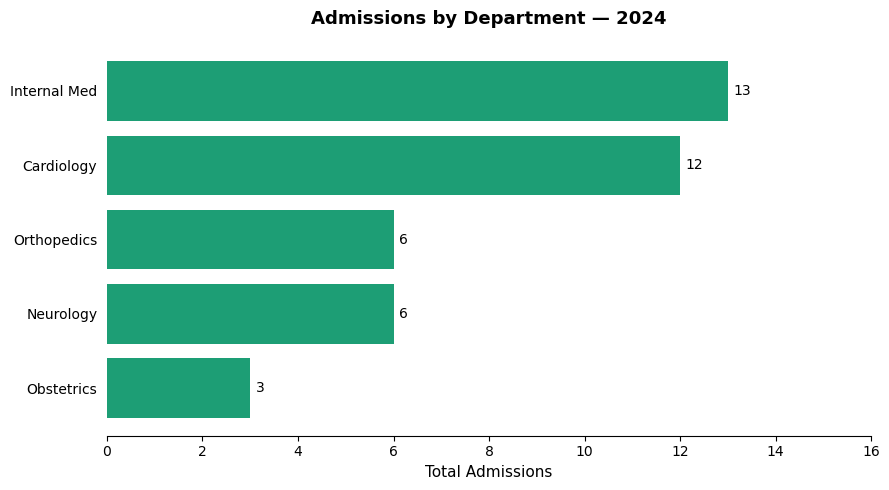

Chart saved as admissions_by_department.png


In [14]:
# ============================================================
# BONUS — Bar chart: admissions by department
# This is the kind of thing you screenshot for your portfolio
# ============================================================

import matplotlib.pyplot as plt

df = run("""
    SELECT department, COUNT(*) AS total_admissions
    FROM admissions
    GROUP BY department
    ORDER BY total_admissions DESC
""")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df['department'], df['total_admissions'], color='#1D9E75', edgecolor='none')
ax.set_xlabel('Total Admissions', fontsize=11)
ax.set_title('Admissions by Department — 2024', fontsize=13, fontweight='bold', pad=14)
ax.bar_label(bars, padding=4, fontsize=10)
ax.invert_yaxis()
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, df['total_admissions'].max() + 3)
plt.tight_layout()
plt.savefig('admissions_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as admissions_by_department.png')

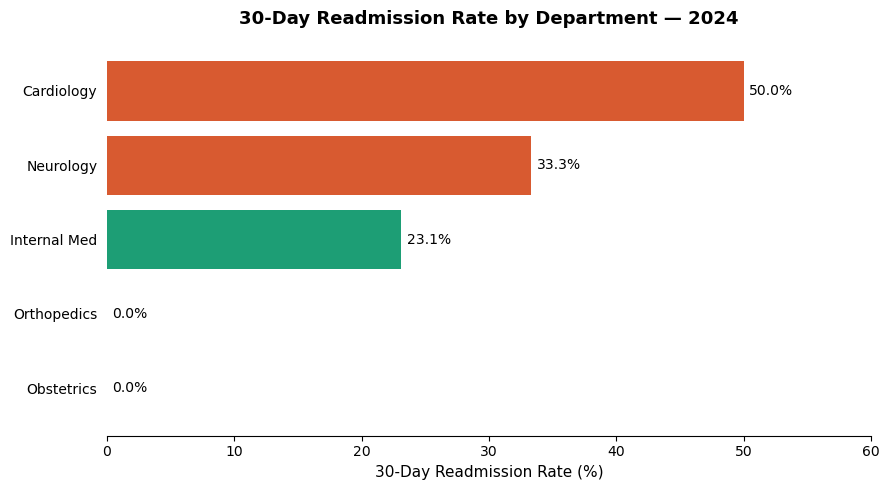

Chart saved as readmission_rate.png


In [15]:
# ============================================================
# BONUS — Bar chart: 30-day readmission rate by department
# ============================================================

df2 = run("""
    WITH readmits AS (
        SELECT DISTINCT a1.patient_id, a1.department, a1.discharge_date
        FROM admissions a1
        JOIN admissions a2
            ON  a1.patient_id = a2.patient_id
            AND a2.admission_date > a1.discharge_date
            AND (JULIANDAY(a2.admission_date) - JULIANDAY(a1.discharge_date)) <= 30
    )
    SELECT
        a.department,
        ROUND(100.0 * COUNT(r.patient_id) / COUNT(*), 1) AS readmit_rate_pct
    FROM admissions a
    LEFT JOIN readmits r
        ON a.patient_id = r.patient_id
        AND a.department = r.department
        AND a.discharge_date = r.discharge_date
    GROUP BY a.department
    ORDER BY readmit_rate_pct DESC
""")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#D85A30' if x >= 30 else '#1D9E75' for x in df2['readmit_rate_pct']]
bars = ax.barh(df2['department'], df2['readmit_rate_pct'], color=colors, edgecolor='none')
ax.set_xlabel('30-Day Readmission Rate (%)', fontsize=11)
ax.set_title('30-Day Readmission Rate by Department — 2024', fontsize=13, fontweight='bold', pad=14)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.invert_yaxis()
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, df2['readmit_rate_pct'].max() + 10)
plt.tight_layout()
plt.savefig('readmission_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as readmission_rate.png')